<h1><center>Modelling and Engineering of Nanoscale Materials <br> Exercises session 5: Advanced MD - 2025 </center></h1>
<center>massimo.bocus@ugent.be,  arnout.maet@ugent.be, thomas.nicholas@ugent.be</center>

In [93]:
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from ase.io import read
from ase.units import *
from pyiron import Project, ase_to_pyiron
import pyiron_gpl

%matplotlib inline

<div class="alert alert-block alert-warning">
<b>Educational Objectives</b> <br> 
(1)  Understand the influence of carelessly assigning the different simulation and thermostat parameters <br>
(2)  Exploring the structure of solid and liquids by means of MD simulations <br>
(3)  Construct the thermal expansion profile for aluminum metal<br>
</div>

## Introduction

In this exercise lesson, we will learn about advanced MD simulations. Starting with the influence of its simulation parameters, exploring what normal MD simulations are useful for, and apply them to larger systems probing their thermodynamic properties.

In [94]:
pr = Project('session5')

## Force field calculations with LAMMPS

<div class="alert alert-block alert-success">
<b>Overview: LAMMPS job</b> <br>   
        
A LAMMPS force field requires two main things:

 * a structure: positions, atomic numbers, cell parameters, etc.
 * a potential file: a list of the atom types in the system and their associated force field parameters.

For these exercise sessions, the pyiron team has collected LAMMPS potentials from literature and made them available for you in the pyiron_resources folder.

The typical structure of a LAMMPS job is the following:
```python
# create the job
job = pr.create_job(job_type=pr.job_type.Lammps, job_name="my_lammps_job", delete_existing_job=True)
# provide a structure
job.structure = my_structure
```

Now we must decide which potential to use. You can have a look at the available parameters using:
```python
job.list_potentials()
job.potential = "my_potential"
```

If you'd like to use your own parameters, you can do so by creating a dataframe with their values:
```python
import pandas
# in this example we explicitly define the tip3p potential for water
water_tip3p = pandas.DataFrame({
    'Name': ['H2O_tip3p'],
    'Filename': [[]],
    'Model': ["TIP3P"],
    'Species': [['H', 'O']],
    'Config': [[
        '# @potential_species H_O ### species in potential\n', 
        '# W.L. Jorgensen et.al., The Journal of Chemical Physics 79, 926 (1983); https://doi.org/10.1063/1.445869\n', 
        '#\n', 
        '\n', 
        'units real\n', 
        'dimension 3\n', 
        'atom_style full\n', 
        '\n', 
        '# create groups ###\n', 
        'group O type 2\n', 
        'group H type 1\n', 
        '\n', 
        '## set charges - beside manually ###\n', 
        'set group O charge -0.830\n', 
        'set group H charge 0.415\n', 
        '\n', 
        '### TIP3P Potential Parameters ###\n', 
        'pair_style lj/cut/coul/long 10.0\n', 
        'pair_coeff * * 0.0 0.0 \n', 
        'pair_coeff 2 2 0.102 3.188 \n', 
        'bond_style harmonic\n', 
        'bond_coeff 1 450 0.9572\n', 
        'angle_style harmonic\n', 
        'angle_coeff 1 55 104.52\n', 
        'kspace_style pppm 1.0e-5\n', 
        '\n'
    ]]
})
job.potential = water_tip3p
```
You can see that the "Config" section contains the actual parameters (electrostatic, covalent, and so on). For example, an harmonic bond with an equilibrium distance of 0.9572 Angstroms and a force constant of 450 kcal/mol. You can explore more in depth what the various commands do in the [LAMMPS documentation](https://docs.lammps.org/Commands_category.html#force-fields), check in particular section 5.4.4 (Force fields).

<div class="alert alert-block alert-danger">
<b>It is very important to define `job.potential` BEFORE defining the job type (e.g., `calc_md`, see below), otherwise there will be a mismatch between units!</b>

<div class="alert alert-block alert-success">
<b>LAMMPS job types</b> <br>
    
LAMMPS in pyiron currently offers three simulation types, i.e. single point energy calculation (`job.calc_static`), geometry optimization (`job.calc_minimize`) and, most importantly, molecular dynamics in various ensembles (`job.calc_md`). An overview is given below:

 * Single point calculation     
```python 
job.calc_static() # no options
```
    
 * Optimization   
```python 
job.calc_minimize(...) # see signature for the possible options
```

 * MD simulation in some ensemble
```python 
job.calc_md(...) # see signature for the possible options
```
</div>

## Exercise 1: The frequency spectrum of diamond

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Run an MD simulation on diamond and inspect the velocity power spectrum. <br>
    2. Play around with the general integration and thermostat parameters to understand their significance.
</div>

In this exercise, the frequency spectrum of diamond will be modeled in the canonical ensemble. The most straightforward way to obtain this frequency spectrum from an MD simulation is by a Fourier transform of the velocity spectrum, yielding the so-called velocity power spectrum (VPS). This spectrum correctly describes the positions of the peaks in the frequency spectrum, but does not yield the correct intensity, which we will not discuss during this exercise.

To simulate the correct frequency spectrum around room temperature on a hot summer day, the canonical ensemble needs to be employed to keep the temperature fixed around 300 K. For this, we will use the Nosé-Hoover thermostat chain with a fixed number of three beads, as this was shown to yield the appropriate ensemble once all other parameters are chosen judiciously.

In what follows, we will first focus on the general properties of the velocity Verlet integration scheme needed to obtain a correct frequency profile. Afterwards, we will look at how the thermostat parameters influence not only the spectrum, but also the quality of the integration and temperature control. **Every simulation should have its own unique job name!**.

In [95]:
# set up project
ex1 = pr.create_group('ex1')

In [96]:
# create a cubic diamond unit cell
diamond = ex1.create.structure.bulk("C", crystalstructure="diamond", cubic=True)
diamond.plot3d(spacefill=False)

NGLWidget()

### General integration properties

<div class="alert alert-block alert-success">
<b>Answer the following questions using the code below:</b> <br>   
<ol type='a'>
<li> Vary the number of times a snapshot of the MD simulations is outputted by changing the <tt>n_print</tt> variable. For the moment, keep all other input parameters unchanged, and run the simulation. You may start from a <tt>temperature_damping_timescale</tt> value of 100 (the timescale of the thermostat is 100 fs). What are the advantages of choosing not to output the system's properties at every simulation time step? Would it make physical sense to do so? </li>
<br>
<li> While the simulation is running, <b>fix</b> the analysis code. Think about how many degrees of freedom are present in the system, taking into account the appropriate conservation laws. Enter the number of degrees of freedom as the variable <tt>ndof</tt>.</li>
<br>
<li> After finishing the simulation, calculate the frequency spectrum of diamond by executing the <tt>plot_velocity_spectrum</tt> function, which visualizes the spectrum. For which values of <tt>n_print</tt> does the frequency spectrum still look as expected, and for which values is a deviation from this behavior observed? How can you explain this? If no deviation is observed, increase the <tt>n_print</tt> variable until you reach the maximum allowed value. </li>
</ol>
</div>

In [97]:
def lammps_MD(pr, n_print, temperature_damping_timescale, nsteps=50000, time_step=1.0, temp=300):
    job = pr.create_job(job_type=pr.job_type.Lammps, job_name="nvt_{:d}_{:d}".format(n_print, temperature_damping_timescale), delete_existing_job=True)
    job.structure = diamond
    job.potential = '2003--Los-J-H--C--LAMMPS--ipr1' # you should be able to see this name using job.list_potentials() after defining the structure
    job.calc_md(
        temperature=temp, # in kelvin
        time_step=time_step, # in fs
        pressure=None, # NVT ensemble
        n_ionic_steps=nsteps, 
        n_print=n_print, # printing frequency
        temperature_damping_timescale=temperature_damping_timescale, # thermostat time constant, in fs
    )
    
    job.server.queue = 'donphan'
    job.executable.version = '2024_mpi'
    job.server.cores = 2
    job.server.run_time = 10*60 # in seconds
    
    job.run()


<div class="alert alert-block alert-info">
<b>Tip - analysis function</b> <br>

Run the `lammps_MD()` function for several combinations of input parameters to answer the questions above.

</div>

Run jobs with different n_print:

In [35]:
lammps_MD(ex1, n_print=1, temperature_damping_timescale=100)

The job nvt_1_100 was saved and received the ID: 1548
Queue system id:  202559464


In [26]:
lammps_MD(ex1, n_print=10, temperature_damping_timescale=100)
lammps_MD(ex1, n_print=20, temperature_damping_timescale=100)

The job nvt_10_100 was saved and received the ID: 1546
Queue system id:  202559434
The job nvt_20_100 was saved and received the ID: 1547
Queue system id:  202559444


In [98]:
job_diamond_nprint_1 = ex1.load("nvt_{:d}_{:d}".format(1, 100))
job_diamond_nprint_10 = ex1.load("nvt_{:d}_{:d}".format(10, 100))
job_diamond_nprint_20 = ex1.load("nvt_{:d}_{:d}".format(20, 100))

In [99]:
# Analysis code
def plot_energy_contributions(job):
    """
    Function to plot the energy contributions (kinetic, potential, and total) during the MD simulation.
        **Arguments**

       job
           job object that contains an MD trajectory of the structure
    """
    output_generic = job["output/generic"]
    energy_pot = output_generic["energy_pot"]
    energy_tot = output_generic["energy_tot"]
    energy_kinetic = energy_tot - energy_pot
    plt.plot(energy_tot, label="energy_tot")
    plt.plot(energy_pot, label="energy_pot")
    plt.legend()
    plt.show()


def plot_velocity_spectrum(job, start=0, end=-1, step=1, bsize=512):
    """
    Convenience function to extract the velocity power spectrum from a MD job.
        **Arguments**

       job
           job object that contains an MD trajectory of the structure

       **Optional arguments:**

       start
            The first sample to be considered for analysis. This may be
            negative to indicate that the analysis should start from the
            -start last samples.

       end
            The last sample to be considered for analysis. This may be
            negative to indicate that the last -end sample should not be
            considered.

       step
            The spacing between the samples used for the analysis

       bsize
            The size of the blocks used for individual FFT calls.

       The block size should be set such that it corresponds to a decent
       resolution on the frequency axis, i.e. 33356 fs of MD data
       corresponds to a resolution of about 1 cm^-1. The step size should be
       set such that the highest frequency is above the highest relevant
       frequency in the spectrum, e.g. a step of 10 fs corresponds to a
       frequency maximum of 3336 cm^-1. The total number of FFT's, i.e.
       length of the simulation divided by the block size multiplied by the
       number of time-dependent functions in the data, determines the noise
       reduction on the (the amplitude of) spectrum. If there is sufficient
       data to perform 10K FFT's, one should get a reasonably smooth
       spectrum.

       Depending on the FFT implementation in numpy, it may be interesting
       to tune the bsize argument. A power of 2 is typically a good choice.
    """
    ssize = bsize // 2 + 1 # the length of the spectrum array
    amplitudes = np.zeros(ssize, float)

    runlength = len(job['output/generic/steps'])
    _start = start if start >= 0 else start + runlength
    _end = end if end >= 0 else end + runlength
    
    # read velocities
    velocities = job.content["output/generic/velocities"] # in A/ps

    # read timestep
    input_dict = job.content["input/control_inp/data_dict"]
    steps = job.content["output/generic/steps"]
    input_dt = float(input_dict["Value"][input_dict["Parameter"].index("timestep")]) # in ps
    dump_interval = steps[1] - steps[0]
    dt_eff = input_dt * dump_interval * step

    current = _start
    stride = step * bsize
    work = np.zeros(bsize, float)
    freqs = np.fft.rfftfreq(bsize, dt_eff) * 1E12 / 29970254700 # 1 / cm
    while current <= _end - stride:
        for idx in np.ndindex(velocities.shape[1:]):
            work = velocities[(slice(current, current+stride, step),) + idx] 
            amplitudes += abs(np.fft.rfft(work))**2
        current += stride

    # plot results
    fig, ax = plt.subplots()
    ax.plot(freqs, amplitudes)
    ax.set_xlabel("Wavenumber [1/cm]")
    ax.set_ylabel("Amplitude [a.u.]")

def plot_temperature_distribution(job):
    """
    Function to plot the temperature distribution observed during a MD job and compare it with the theoretical one.
    It relies on the plot_temp_dist function, pre-implemented in pyiron_gpl.
        **Arguments**

       job
           job object that contains an MD trajectory of the structure
    """
    
    from pyiron_gpl.utils.md_analysis import plot_temp_dist
    N = job["output/generic/natoms"][-1]
    ndof = 3*N - 3
    temp = np.mean(job["output/generic/temperature"])
    plot_temp_dist(job, ndof=ndof, temp=temp)

Figure 1 from solutions

/tmp/ipykernel_1252043/7104513.py:64: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  runlength = len(job['output/generic/steps'])


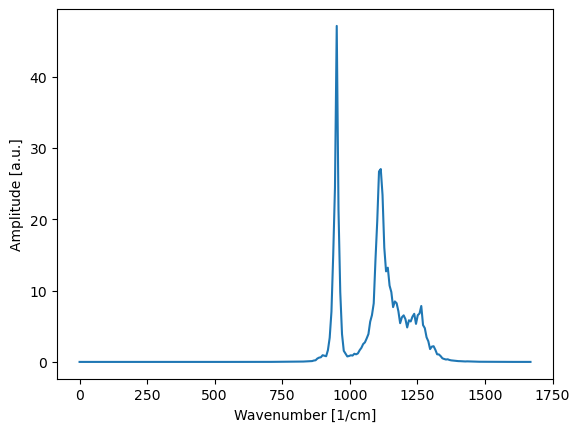

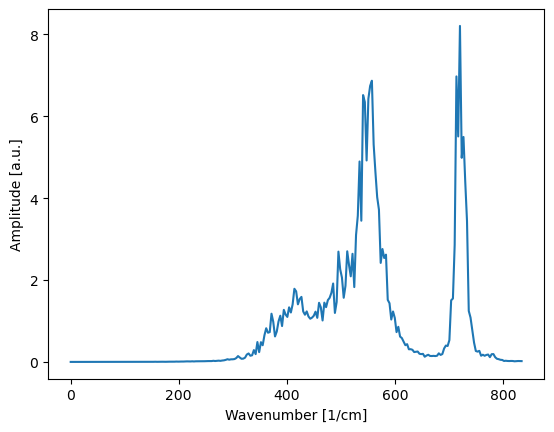

In [100]:
plot_velocity_spectrum(job_diamond_nprint_10, step=1)
plot_velocity_spectrum(job_diamond_nprint_20, step=1)

/tmp/ipykernel_1252043/7104513.py:64: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  runlength = len(job['output/generic/steps'])


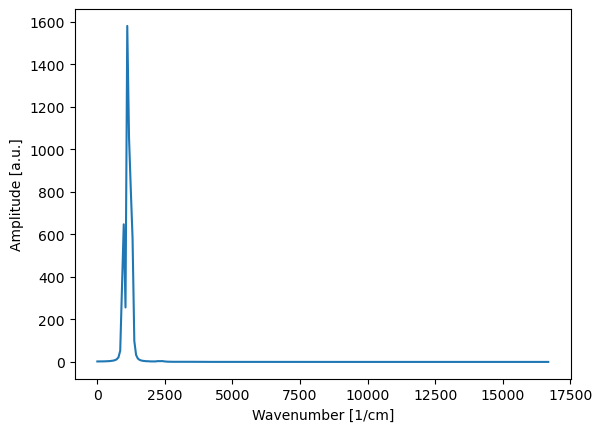

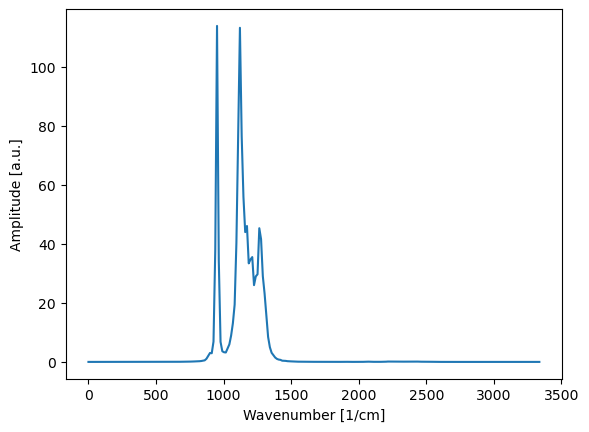

In [101]:
# further improving resolution is not necessary fro frequency spectrum (no more Nyquist aliasing)
plot_velocity_spectrum(job_diamond_nprint_1, step=1)
plot_velocity_spectrum(job_diamond_nprint_1, step=5)

### Thermostat integration properties

<div class="alert alert-block alert-success">
<b>Answer the following questions using the code below:</b> <br>   
<ol start=4>
<li> Using the highest value of <tt>n_print</tt> that yielded a good frequency spectrum, determine the influence of the thermostat relaxation time by altering the <tt>temperature_damping_timescale</tt> keyword. Try both to increase and to decrease this relaxation time, which is an indication of how strongly the thermostat interferes with the system. Can you deduce, by looking at the temperature distribution generated by executing the analysis code, whether a high relaxation time means a small disturbance of the unthermostatted system or a large disturbance? Take both the mean temperature as well as the complete temperature distribution into account. </li>
<br>
<li> For the given set of thermostat relaxation times, look at the total energy of the simulation. How do you interpret your results? </li>
<br>
<li> Now take a look at the influence of the thermostat relaxation time on the frequency spectrum. Does it change? If so, why do you think that is the case? </li>
<br>
<li> Based on the observations you made here, can you give a working range of relaxation times for the thermostat? How do you think this range depends on the molecule you are considering?  </li>
</ol>
</div>

In [14]:
# simulate for different thermostat timescale
lammps_MD(ex1, n_print=10, temperature_damping_timescale=10000)

The job nvt_10_10000 was saved and received the ID: 1549
Queue system id:  202561564


In [102]:
job_diamond_nprint_10_100 = ex1.load("nvt_{:d}_{:d}".format(10, 100))
job_diamond_nprint_10_10000 = ex1.load("nvt_{:d}_{:d}".format(10, 10000))

In [103]:
plot_temperature_distribution(job_diamond_nprint_10_100)

ModuleNotFoundError: No module named 'pyiron_gpl.utils'

/tmp/ipykernel_1252043/7104513.py:10: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  output_generic = job["output/generic"]


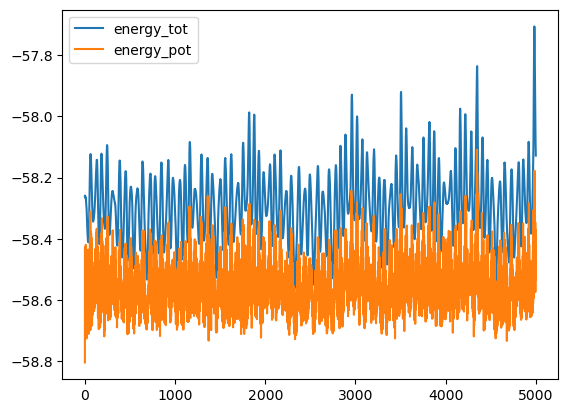

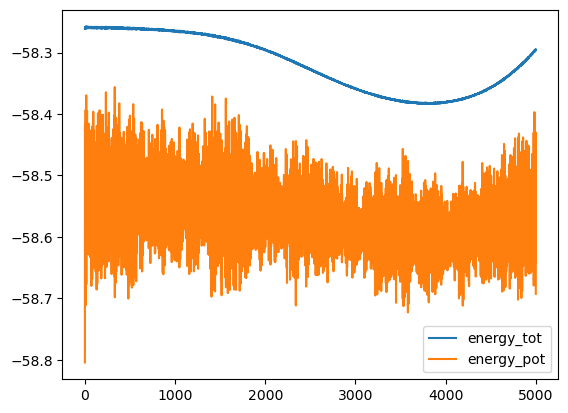

In [104]:
plot_energy_contributions(job_diamond_nprint_10_100)
plot_energy_contributions(job_diamond_nprint_10_10000)

## Exercise 2: The radial distribution function to observe loss of crystallinity

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Qualitatively compare the RDFs of UiO-66 for two different sets of conditions
</div>

In this exercise, we will compare the radial distribution function of UiO-66, based on two different simulations in the $(N,V,\boldsymbol{\sigma_{a}}=\boldsymbol{0},T)$ ensemble which have already been performed for you. In one of the simulations, we chose a low volume, inside the amorphization region, while the other simulation was carried out for a volume close to the equilibrium volume at room temperature and atmospheric pressure. The aim of this exercise is to understand how RDFs may help you to identify the onset of amorphization, if present during a simulation. 

To be able to generate the RDFs, you may use the RDF code below. Look at the arguments that have to be provided for the function to work as intended. We will use a **dummy polonium atom** (this atom was chosen randomly, as it is normally not encountered in this MOF; please do not try to do this experimentally) as a reference point for the RDF from which all distances are calculated.

Use the code below to plot the RDFs at both volumes separately. **These RDFs are calculated between a given type of atom (either zirconium, oxygen, carbon or hydrogen) and the dummy atom**, and each of the four RDFs for a given volume is plotted in a different color. Visualize the structure, using ASE to read a structure from the trajectory files, and assign each peak to a given atom type (for as far as the peaks are well resolved).

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Can you identify which volume corresponds to the amorphization region? At which distance does this loss of crystallinity take place? Is this in correspondence with your physical intuition? </li>
<br>
<li> What would happen if you vary the maximum radial distance for which the RDF is calculated? What is the maximal distance for which a qualitatively similar picture will emerge between both configurations? </li>
</ol>
</div>

In [105]:
def compute_rdf_ase(traj, rmax=None, width=None, elements=None, coordination_number=False):
    from ase import Atoms
    from ase.geometry.analysis import Analysis
    """
    Plot the radial distribution function of a set of atoms.

    **Arguments**
    trajectory
        An ASE trajectory.
    
    **Optional arguments**
    rmax
        The cutoff radius to compute the RDF, in angstrom (if None => half of the shortest unit cell vector of the last frame)
    width
        The resolution of the RDF bins (if None => rmax / 100)
    elements
        The elements among which the RDF should be computed.  If elements is an integer or a list/tuple of integers, only those atoms will contribute to the RDF (like a mask). If elements is a string or a list/tuple of strings, only Atoms of those elements will contribute.
    start, end, step
        Compute the RDF slicing the trajectory according to slice(start, stop, step)
    """  
    if rmax is None:
        rmax = (np.min(traj[-1].cell.cellpar()[:3]) / 2) * 0.99
    if width is None:
        width = rmax / 100

    nbins = rmax // width
    analysis = Analysis(traj)
    rdf_data = analysis.get_rdf(rmax, int(nbins), elements=elements, return_dists=True)
    rdfs, distances_list = zip(*rdf_data)
    rdf = np.mean(rdfs, axis=0)
    distances = distances_list[0]

    # normalization
    N = len(traj[0])
    N_B = int((traj[0].numbers == elements[1]).sum())
    rdf *= (N / N_B)

    if coordination_number:
        # compute coordination number
        species_count = sum(sym == "O" for sym in traj[-1].get_chemical_symbols())
        rho = species_count / traj[-1].get_volume()
        coordination_number = np.cumsum(rdf * rho * (4 * np.pi * distances**2 * width))
        return distances, rdf, coordination_number

    else:
        return distances, rdf

In [106]:
atoms = read("session5_input/ex2/vol1.xyz")
atoms = ase_to_pyiron(atoms)
atoms.plot3d()

NGLWidget()

In [107]:
atoms = read("session5_input/ex2/vol2.xyz")
atoms = ase_to_pyiron(atoms)
atoms.plot3d()

NGLWidget()

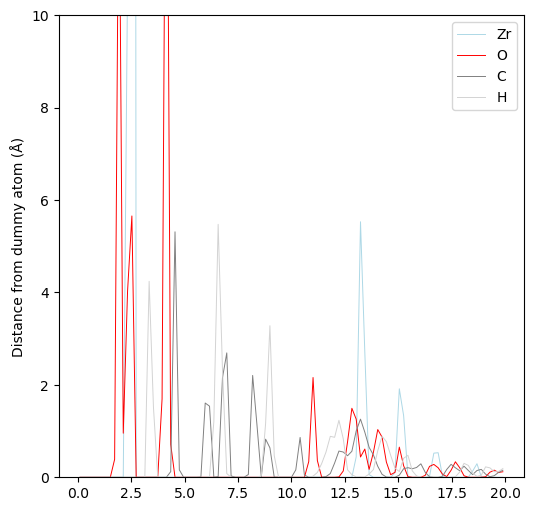

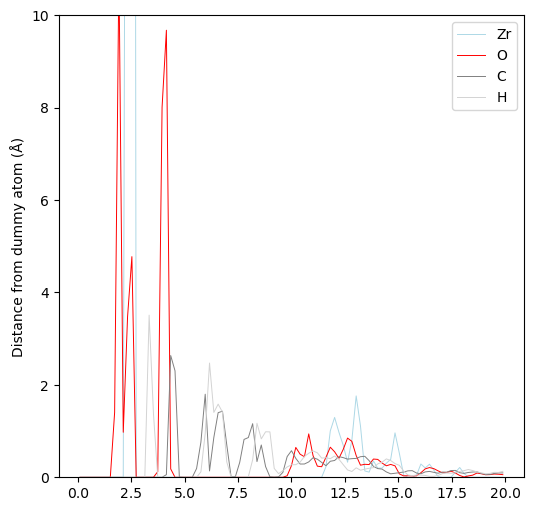

In [111]:
# larger volume
trajectory_1 = read("session5_input/ex2/vol1.xyz", index=":")
trajectory_2 = read("session5_input/ex2/vol2.xyz", index=":")

def plot_RDFs(trajectory):
    ## compute the desired RDFs from the trajectory and plot them
    elements = [40, 8, 6, 1]
    colors=["lightblue", "red", "gray", "lightgray"]
    element_names = ["Zr", "O", "C", "H"]
    
    plt.figure(figsize=(6, 6)) 
    for i, element in enumerate(elements):
        distances, rdf = compute_rdf_ase(trajectory, rmax=20, width=None, elements=[element, 84], coordination_number=False)
        plt.plot(distances, rdf, color=colors[i], label=element_names[i], linewidth=0.7)
    plt.ylabel("RDF (a.u.)")
    plt.ylabel("Distance from dummy atom (Å)")
    plt.ylim(0, 10)
    plt.legend()
    plt.show()

plot_RDFs(trajectory_1)
plot_RDFs(trajectory_2)

Experimentally, we (rarely) have access to the pair correlations directly. For example, in a X-ray or neutron total scattering experiment, we would record the weighted sum of all pair correlations in your sample. From our rdf functions, we can compute the pattern we would expect from, e.g., a neutron experiment.

In [112]:
def neutron_pdf(trajectory, deuterate: bool = True):
    """
    Compute the neutron pair distribution function from the trajectory.
    
    **Arguments**
    trajectory
            An ASE trajectory.

    **Optional arguments**
    deuterate
        Whether to use the neutron scattering length of deuterium (True) or 
        hydrogen (False).
    """

    def c_i(atoms, element: int) -> float:
        """ Atomic fraction of element in the structure. """
        return (atoms.numbers==element).sum() / len(atoms)
    
    elements = (6, 1, 8, 40)
    unique_pairs = [(a, b) for i, a in enumerate(elements) for b in elements[i:]]
    
    pair_rdfs = defaultdict(list)
    for pair in unique_pairs:
        _rs, _rdf = compute_rdf_ase(trajectory, rmax=20, elements=list(pair))
        pair_rdfs[pair] = _rdf

    rs = _rs

    neut_coeff = {
        1: -3.7406, # fm
        6:   6.6460, # fm
        8:   5.8030, # fm
        40:  7.16,   # fm
    }

    if deuterate:
        neut_coeff[1] = 6.671
    
    _fm_to_m = 1e-15

    constants = np.array([
        4 * np.pi * 1e28
        * (2 - int(i==j))
        * neut_coeff[i]
        * neut_coeff[j]
        * _fm_to_m
        * _fm_to_m
        * c_i(trajectory[0], i)
        * c_i(trajectory[0], j)
        for i, j in unique_pairs
    ])

    partials = np.array(list(pair_rdfs.values()))
    total_gr = ((partials - 1.0) * constants[:, None]).sum(axis=0)

    return (rs, total_gr)

In [113]:
## compute the neutron PDFs for both volumes and plot them.

rs1, total_gr1 = neutron_pdf(trajectory_1)
rs2, total_gr2 = neutron_pdf(trajectory_2)

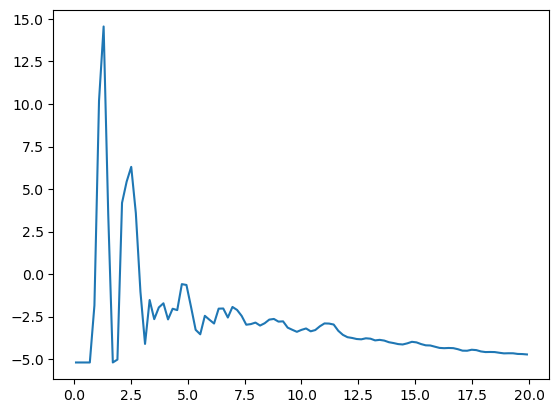

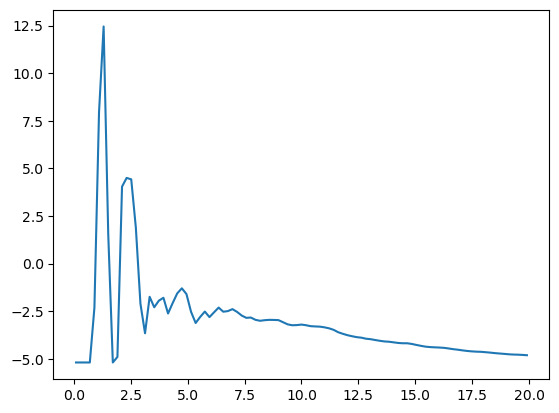

In [114]:
plt.plot(rs1, total_gr1)
plt.show()

plt.plot(rs2, total_gr2)
plt.show()

## Exercise 3: Is water a liquid according to the radial distribution function? 

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Calculate the RDF for water <br>
    2. Inspect the RDF between different atoms and consider the (absence of) long-range order
</div>

In this exercise we will use a dedicated water force field, called TIP-3P, to calculate the radial distribution of a box with water molecules. As before, we will check the energy behavior and temperature distribution. Below you will find the code to run the MD simulation, consisting of two distinct stages, an initialization and production run.

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Why do we need a shorter timestep for the initialization? Connect this to the potential energy surface of the system.  </li>
<br>
<li> What happens to the energy and temperature of the system during this simulation?</li>
<br>
<li> Based on the RDF, would you say that water is a solid, a liquid or a gas? Why?  </li>
<br>
<li> What do the different peaks in the RDF correspond to? </li>
</ol>
</div>

In [216]:
ex3 = pr.create_group('ex3')

### Question 1

In [219]:
# Input parameters
density = 1e6 * (1e-10)**3   #g/A^3
n_molecules = 64
mol_mass_water = 18  # g/mol, FIX ME

# Determining the supercell size size
mass = mol_mass_water * n_molecules / mol  # g
vol_h2o = mass / density # in A^3
a = vol_h2o ** (1./3.) # A

# Constructing the unitcell
n = int(round(n_molecules ** (1. / 3.)))

dx = 0.7
r_O = [0, 0, 0]
r_H1 = [dx, dx, 0]
r_H2 = [-dx, dx, 0]
unit_cell = (a / n) * np.eye(3)
water = pr.create.structure.atoms(elements=['H', 'H', 'O'], positions=[r_H1, r_H2, r_O], cell=unit_cell)
water = water.repeat([n, n, n])
water.plot3d()

NGLWidget()

In [220]:
init_nvt = ex3.create_job(pr.job_type.Lammps, "init", delete_existing_job=True)
init_nvt.structure = water

In [221]:
import pandas
# in this example we explicitly define the tip3p potential for water
water_tip3p = pandas.DataFrame({
    'Name': ['H2O_tip3p'],
    'Filename': [[]],
    'Model': ["TIP3P"],
    'Species': [['H', 'O']],
    'Config': [[
        '# @potential_species H_O ### species in potential\n', 
        '# W.L. Jorgensen et.al., The Journal of Chemical Physics 79, 926 (1983); https://doi.org/10.1063/1.445869\n', 
        '#\n', 
        '\n', 
        'units real\n', 
        'dimension 3\n', 
        'atom_style full\n', 
        '\n', 
        '# create groups ###\n', 
        'group O type 2\n', 
        'group H type 1\n', 
        '\n', 
        '## set charges - beside manually ###\n', 
        'set group O charge -0.830\n', 
        'set group H charge 0.415\n', 
        '\n', 
        '### TIP3P Potential Parameters ###\n', 
        'pair_style lj/cut/coul/long 10.0\n', 
        'pair_coeff * * 0.0 0.0 \n', 
        'pair_coeff 2 2 0.102 3.188 \n', 
        'bond_style harmonic\n', 
        'bond_coeff 1 450 0.9572\n', 
        'angle_style harmonic\n', 
        'angle_coeff 1 55 104.52\n', 
        'kspace_style pppm 1.0e-5\n', 
        '\n'
    ]]
})
init_nvt.potential = water_tip3p

/kyukon/data/gent/courses/2025/nanoscale_E006800/input/pyiron_env/envs/_pyiron_env/lib/python3.12/site-packages/pyiron_atomistics/lammps/base.py:138: UserWarning: Non-'metal' units are not fully supported. Your calculation should run OK, but results may not be saved in pyiron units.
  warnings.warn(


In [222]:
init_nvt.calc_md(temperature=300, n_ionic_steps=1E4, time_step=0.01) # timestep in fs
init_nvt.executable.version = '2024_mpi'
init_nvt.server.queue = 'donphan'
init_nvt.server.cores = 2 # lammps can handle more than 1 core in parallel
init_nvt.server.run_time = 5*60 # in seconds
init_nvt.run()

The job init was saved and received the ID: 1632
Queue system id:  202563394


In [223]:
# Visualize the MD trajectory
init_nvt.animate_structures()

NGLWidget(max_frame=100)

Now that we have a reasonable initial structure, the timestep can be increased allowing bigger timescales and for the equilibration of the structure during the production run.

In [237]:
eq_nvt = ex3.create_job(pr.job_type.Lammps, "eq", delete_existing_job=True)
eq_nvt.structure = init_nvt.get_structure(iteration_step=-1)
eq_nvt.potential = init_nvt.potential
eq_nvt.executable.version = '2024_mpi'
eq_nvt.calc_md(temperature=300, n_ionic_steps=2e4, n_print=10, time_step=0.5)
eq_nvt.server.queue = 'donphan'
eq_nvt.server.cores = 2 # lammps can handle more than 1 core in parallel
eq_nvt.server.run_time = 5*60 # in seconds
eq_nvt.run()

/tmp/ipykernel_1252043/1116237861.py:2: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.HasStructure.get_structure(iteration_step=-1) is deprecated.
  eq_nvt.structure = init_nvt.get_structure(iteration_step=-1)


The job eq was saved and received the ID: 1633
Queue system id:  202563464


In [238]:
# Visualize the MD trajectory
eq_nvt.animate_structures()

NGLWidget(max_frame=2000)

Plot the energy and the temperature of the system

### Question 2

/tmp/ipykernel_1252043/1447029.py:3: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  temp_init = init_nvt["output/generic/temperature"]
/tmp/ipykernel_1252043/1447029.py:4: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  temp_prod = eq_nvt["output/generic/temperature"]


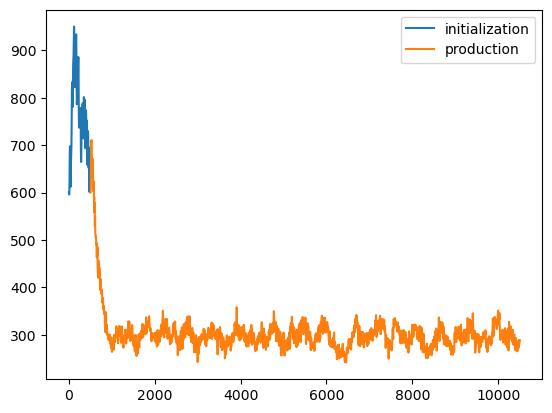

/tmp/ipykernel_1252043/1447029.py:12: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  energy_pot_init = init_nvt["output/generic/energy_pot"]
/tmp/ipykernel_1252043/1447029.py:13: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  energy_pot_prod = eq_nvt["output/generic/energy_pot"]


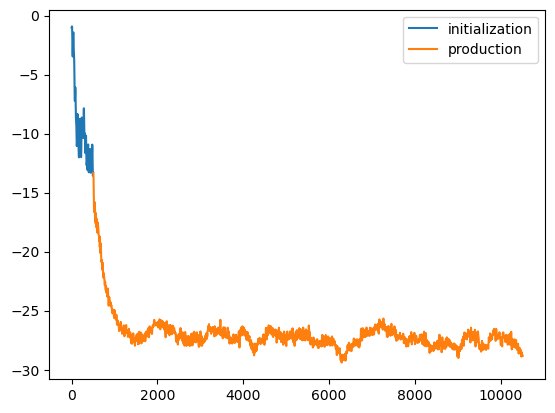

In [240]:
timescale = 5
# temperature plot
temp_init = init_nvt["output/generic/temperature"]
temp_prod = eq_nvt["output/generic/temperature"]

plt.plot(np.arange(len(temp_init))*timescale, temp_init, label="initialization")
plt.plot((np.arange(len(temp_prod)) + len(temp_init))*timescale, temp_prod, label="production")
plt.legend()
plt.show()

# energy plot
energy_pot_init = init_nvt["output/generic/energy_pot"]
energy_pot_prod = eq_nvt["output/generic/energy_pot"]

plt.plot(np.arange(len(energy_pot_init))*timescale, energy_pot_init, label="initialization")
plt.plot((np.arange(len(energy_pot_prod)) + len(energy_pot_init))*timescale, energy_pot_prod, label="production")
plt.legend()
plt.show()

### Question 3

<div class="alert alert-block alert-info">
<b>Remember - creating RDFs</b> <br>
    
The RDF during an MD simulation can be computed by executing:

```python
distances, rdf = compute_rdf_ase(trajectory)
plt.plot(distances, rdf)
```

The function is meant to be used with an ASE trajectory. For your convenience, we provide hereafter a function to extract a trajectory in ASE format from a pyiron job. Since we are dealing with a liquid and the rdf should therefore converge to 1, you might want to set the `normalize` flag to `True`.
</div>

For comparison purposes, we also provide you with an experimental O-O RDF in the input folder. You may load the file using numpy (`np.loadtxt`), the first column of the array will contain the distance while the second the RDF values.

In [241]:
def pyiron_to_ase(job, start=0, end=-1, step=1):
    from ase import Atoms
    """
    Extract a trajectory from a pyiron job, in ASE format.

    **Arguments**
    job
        A pyiron job.
    """
    positions = job.content["output/generic/positions"][start:end:step]
    cells = job.content["output/generic/cells"][start:end:step]
    species = job.content["output/structure/species"]
    indices = job.content["output/structure/indices"]
    chemical_symbols = [species[i] for i in indices]

    # convert the pyiron job output attributes to a list of atoms
    traj = []
    for i, position in enumerate(positions):
        atoms = Atoms(symbols=chemical_symbols, positions=position, cell=cells[i], pbc=True)
        traj.append(atoms)
    return traj

In [ ]:
traj_ase_eq_nvt = pyiron_to_ase(eq_nvt)

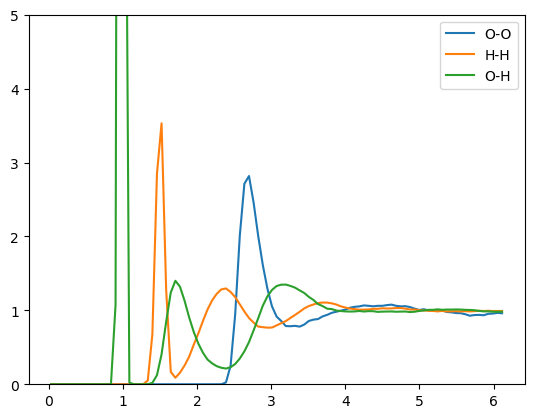

In [244]:
# takes a long time (4 minutes)!!!

## compute the desired RDFs from the trajectory and plot them
def plot_rdf(elements, label):
    distances, rdf = compute_rdf_ase(traj_ase_eq_nvt, rmax=None, width=None, elements=elements, coordination_number=False)
    plt.plot(distances, rdf, label=label)

plot_rdf(elements=[8, 8], label="O-O")
plot_rdf(elements=[1, 1], label="H-H")
plot_rdf(elements=[1, 8], label="O-H")

plt.ylim(0, 5)
plt.legend()
plt.show()

## Exercise 4: The thermal expansion of aluminum

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Calculate the volumetric thermal expansion coefficient of Al metal <br>
</div>

In this exercise, you will calculate the volumetric thermal expansion coefficient of Al. This quantity is defined as (units = K$^{-1}$):

\begin{equation}
 \alpha_V = \frac{\partial{\left(\ln V\right)}}{\partial{T}}
\end{equation}

You should know all commands to perform these simulations yourself. However, instead of an $NVT$ simulation we will now control the pressure in an $(N,P,\boldsymbol{\sigma}_a = \boldsymbol{0},T)$ simulation. Aside from pressure instead of volume control, this ensemble allows the cell shape to change, which is important for anisotropic solids (not that important for Al).

Use a timeconstant of **100 fs for the thermostat**, and a timeconstant of **1000 fs for the barostat**. Generally, barostat timeconstants will be larger than thermostat timeconstants. This originates from the fact that thermostats influence particles individually, whereas barostats interact with the system as a whole. Since the timeconstant is a measure for the inertia, it makes sence that the barostat has a larger timeconstant. Take care when using similar timeconstants for both thermostat and barostat, because this will cause them to interact. You may look at the available potentials for your structure using `job.list_potentials()` and select any of them (you may compare the results of different potentials if you wish).

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Perform a series of $(N,P,\boldsymbol{\sigma}_a = \boldsymbol{0},T)$ simulations in a temperature range of 100 to 400 Kelvin at atmospheric pressure, plot the resulting $V(T)$ profile and derive the volumetric expansion coefficient.  </li>
<br>
<li> Can you get a measure for the error on a single $V(T)$ point? </li>
<br>
<li> How do you know the average volume has converged? </li>
</ol>
</div>

In [118]:
ex4 = pr.create_group('ex4')

### Question 1

In [119]:
Al = pr.create.structure.bulk("Al", cubic=True)
Al_supercell = Al.repeat([3, 3, 3])
Al_supercell.plot3d()

NGLWidget()

In [133]:
job_filler = pr.create_job(job_type=pr.job_type.Lammps, job_name="namnam")
job_filler.structure = Al_supercell
#job_filler.calc_md??
job_filler.list_potentials()
potential = '1999--Mishin-Y--Al--LAMMPS--ipr1'

In [134]:
# adapt you lammps_MD function to perform NPT simulations
def lammps_MD_NPT(pr, n_print, structure, potential, temperature_damping_timescale, pressure_damping_timescale, nsteps=50000, time_step=1.0, temp=300, pressure=1.0):
    job = pr.create_job(job_type=pr.job_type.Lammps, job_name="npt_%.3g" % (temp), delete_existing_job=True)
    job.structure = structure
    job.potential = potential # you should be able to see this name using job.list_potentials() after defining the structure
    job.calc_md(
        temperature=temp, # in kelvin
        time_step=time_step, # in fs
        pressure=pressure, # NVT ensemble
        n_ionic_steps=nsteps, 
        n_print=n_print, # printing frequency
        temperature_damping_timescale=temperature_damping_timescale, # thermostat time constant, in fs
        pressure_damping_timescale=pressure_damping_timescale        # barostat time constant, in fs
    )
    
    job.server.queue = 'donphan'
    job.executable.version = '2024_mpi'
    job.server.cores = 2
    job.server.run_time = 30*60 # in seconds
    
    job.run()

In [135]:
n_print=100
temperature_linspace = np.linspace(100, 400, 10)
for i, temperature in enumerate(temperature_linspace):
    job_iteration = lammps_MD_NPT(ex4, n_print=n_print, structure = Al_supercell, potential=potential, temperature_damping_timescale = 100, pressure_damping_timescale=1000, temp = temperature, pressure=1.0)

The job npt_100 was saved and received the ID: 1622
Queue system id:  202563164
The job npt_133 was saved and received the ID: 1623
Queue system id:  202563174
The job npt_167 was saved and received the ID: 1624
Queue system id:  202563184
The job npt_200 was saved and received the ID: 1625
Queue system id:  202563194
The job npt_233 was saved and received the ID: 1626
Queue system id:  202563204
The job npt_267 was saved and received the ID: 1627
Queue system id:  202563214
The job npt_300 was saved and received the ID: 1628
Queue system id:  202563224
The job npt_333 was saved and received the ID: 1629
Queue system id:  202563234
The job npt_367 was saved and received the ID: 1630
Queue system id:  202563244
The job npt_400 was saved and received the ID: 1631
Queue system id:  202563254


In [144]:
volumes = []
volumes_steps = {}
for i, temperature in enumerate(temperature_linspace):
    temp = temperature
    job_name="npt_%.3g" % (temp)
    job = ex4.load(job_name)
    print(job.status)
    output_generic_volume = job["output/generic/volume"]
    volume = np.mean(output_generic_volume)
    volumes.append(volume)
    volumes_steps[temp] = output_generic_volume

finished
finished
finished
finished


/tmp/ipykernel_1252043/291537228.py:9: DeprecationWarning: pyiron_base.jobs.job.base.__getitem__ is deprecated: Use job.output for results, job.files to access files; job.content to access HDF storage and job.child_project to access children of master jobs..
  output_generic_volume = job["output/generic/volume"]


finished
finished
finished
finished
finished
finished


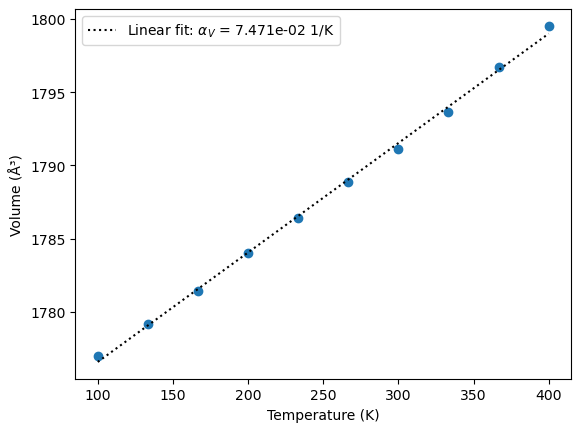

In [143]:
# linear regression
slope, intercept = np.polyfit(temperature_linspace, volumes, 1)

plt.plot(temperature_linspace, slope*temperature_linspace + intercept, color='black', label=f"Linear fit: $α_V$ = {slope:.3e} 1/K", linestyle="dotted")
plt.scatter(temperature_linspace, volumes)
plt.xlabel("Temperature (K)")
plt.ylabel("Volume (Å³)")
plt.legend()
plt.show()

### Question 2
(Adapted code from the solutions)

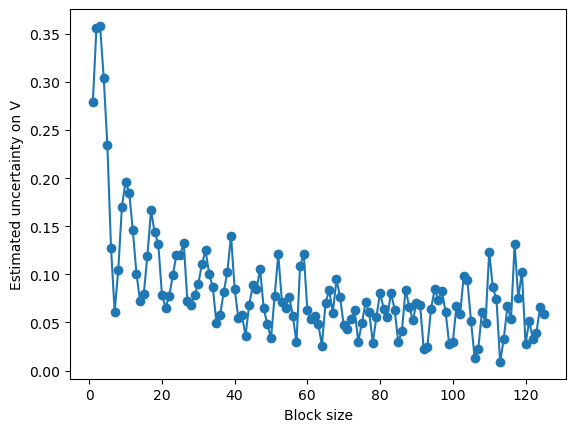

In [167]:
def block_average_test(data, max_block_size=None):
    "test different block sizes"
    data = np.array(data)
    n = len(data)
    if max_block_size is None:
        max_block_size = n // 4
    block_sizes = []
    std_errors = []
    for block_size in range(1, max_block_size + 1):
        block_sizes.append(block_size)
        std_error, _ = block_average_uncertainty(data, block_size)
        std_errors.append(std_error)
    return block_sizes, std_errors
                          
def block_average_uncertainty(data, block_size):
     # Calculate number of complete blocks
     n = len(data)
     n_blocks = n // block_size
     # Compute block averages
     block_avgs = []
     for i in range(n_blocks):
        block = data[i * block_size:(i + 1) * block_size]
        block_avgs.append(np.mean(block))
     # Standard error of block averages
     std_error = np.std(block_avgs, ddof=1) / np.sqrt(n_blocks)
     return std_error, block_avgs

# example plot to test ideal block size
volumes = volumes_steps[100]
block_sizes, std_errors  = block_average_test(volumes)
plt.plot(block_sizes, std_errors, marker='o')
plt.xlabel("Block size")
plt.ylabel("Estimated uncertainty on V")
plt.show()

### Question 3
Now plot the averages: block average, rolling average and moving average

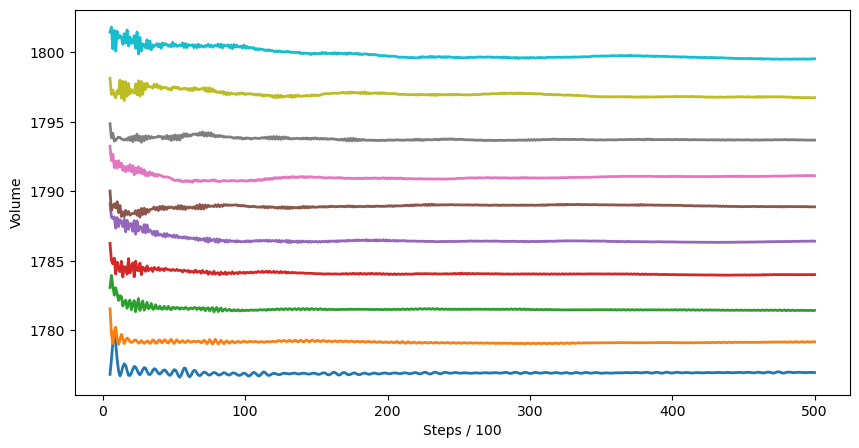

In [214]:
def rolling_average(x):
    return np.cumsum(x) / np.arange(1, len(x)+1)

plt.figure(figsize=(10,5))
for temp in volumes_steps.keys():
    volumes = volumes_steps[temp]
    V_ra = rolling_average(volumes)
    initial_window = 5 # don't plot the initial values of the rolling average to avoid initials spurious results
    plt.plot(np.arange(len(V_ra[initial_window:])) + initial_window, V_ra[initial_window:], linewidth=2)
plt.xlabel('Time step')
plt.ylabel('Volume')
plt.xlabel("Steps / 100")
plt.show()

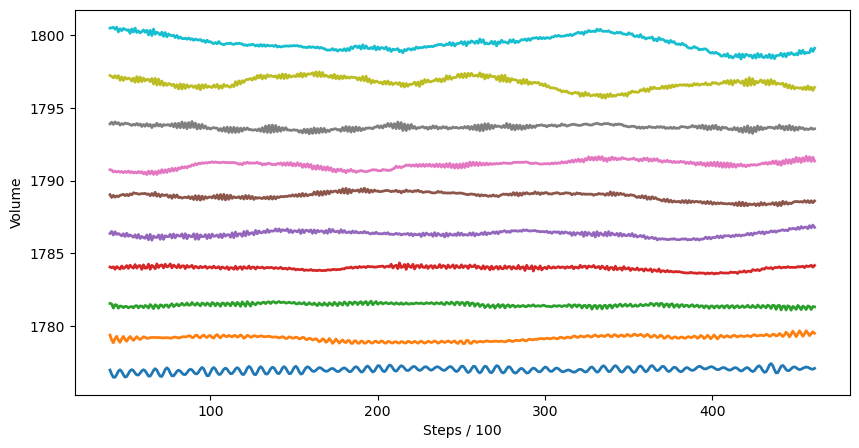

In [215]:
def moving_average(x, window):
    return np.convolve(x, np.ones(window)/window, mode='valid')

# Window size (number of steps)
window = 80
plt.figure(figsize=(10,5))
for temp in volumes_steps.keys():
    volumes = volumes_steps[temp]
    V_ma = moving_average(volumes, window)
    plt.plot(np.arange(len(V_ma)) + window//2, V_ma, linewidth=2)
plt.xlabel('Time step')
plt.ylabel('Volume')
plt.xlabel("Steps / 100")
plt.show()